# GIWAXS q-image diagnostic

This notebook is the reference plot for a reduced `q_image/*.npz` file. It makes the geometry explicit: the array rows are `qz`, the columns are `qx`, and the stored mask plus non-positive remesh pixels are hidden. The loader normalizes the current SMI convention where `qimg_mask=True` marks valid remeshed pixels.

Edit `DATA_ROOT` in the next cell, then run top to bottom.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Make the repository importable when JupyterLab starts in the repo or notebook/ directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / 'NanoOrganizer').is_dir():
        sys.path.insert(0, str(candidate))
        break

from NanoOrganizer.viz.scattering_notebook import (
    load_qimage, load_qphi, plot_qimage, plot_qphi, plot_cir_avg,
    qimage_linecuts, qimage_stats, product_index, valid_intensity,
)

DATA_ROOT = Path('/home/yuzhang/NSLS_II_Link/smi_remote/2026-2/pass-319371/projects/microbeam_Kim/Results/giwaxs')
FRAME_INDEX = 0
MAX_PLOT_PIXELS = 600_000

## 1. Product inventory

This confirms that the folder contains the products expected by the GUI and shows the common frame index.

In [2]:
frame_table = product_index(DATA_ROOT)
if frame_table.empty:
    raise FileNotFoundError(f'No scattering products found below {DATA_ROOT}')
if not 0 <= FRAME_INDEX < len(frame_table):
    raise IndexError(f'FRAME_INDEX={FRAME_INDEX} is outside 0..{len(frame_table) - 1}')
counts = {
    product: int(frame_table[f'has_{product}'].sum())
    for product in ('qc', 'q_image', 'qphi', 'cir_avg')
    if f'has_{product}' in frame_table
}
print('Product counts:', counts)
display(frame_table.head())

Product counts: {'qc': 994, 'q_image': 994, 'qphi': 994, 'cir_avg': 994}


,stem,stitched,has_stitched,qc,has_qc,q_image,has_q_image,qphi,has_qphi,cir_avg,has_cir_avg
0,Kim_EUV_10_0.0500deg_x-30160.00_y1770.66_z1600...,None,False,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True
1,Kim_EUV_10_0.0500deg_x-30160.00_y1770.66_z1600...,None,False,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True
2,Kim_EUV_10_0.0500deg_x-30660.00_y1770.66_z1600...,None,False,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True
3,Kim_EUV_10_0.0500deg_x-31160.00_y1770.66_z1600...,None,False,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True
4,Kim_EUV_10_0.1000deg_x-30160.00_y1770.66_z1600...,None,False,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True,/mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...,True


## 2. Load one q-image and inspect its geometry

In [3]:
if frame_table.empty or not bool(frame_table.iloc[FRAME_INDEX].get('has_q_image', False)):
    raise FileNotFoundError(f'No q-image product is available for frame index {FRAME_INDEX}')
qimage_path = Path(frame_table.iloc[FRAME_INDEX]['q_image'])
qimage = load_qimage(qimage_path)
print('Selected:', qimage_path.name)
display(pd.Series(qimage_stats(qimage), name='value'))
print('qimg shape:', qimage.intensity.shape, 'mask shape:', None if qimage.mask is None else qimage.mask.shape)

Selected: qimg_Kim_EUV_10_0.0500deg_x-30160.00_y1770.66_z1600.00_det5000.00m_waxsSTITCH_expt5s__16.10keV_wa00.0_sdd5.0m_16100.00eV_wa-0.0_sdd5000.0mm_id1149122_000000_WAXS.tif.npz


rows              3.031000e+03
columns           4.414000e+03
qx_min           -2.242806e+00
qx_max            6.792656e+00
qz_min           -1.121231e+00
qz_max            5.082587e+00
valid_pixels      7.925062e+06
valid_fraction    5.923582e-01
p01               2.269882e+02
median            5.420992e+02
p999              2.777411e+03
Name: value, dtype: float64

qimg shape: (3031, 4414) mask shape: (3031, 4414)


## 3. Reference q-image plots

The left plot uses `LogNorm` and robust 1–99.5 percentile limits. The right plot is linear. `aspect='auto'` is intentional: qx and qz have different physical spans, so forcing a square pixel aspect can make the map appear visually compressed.

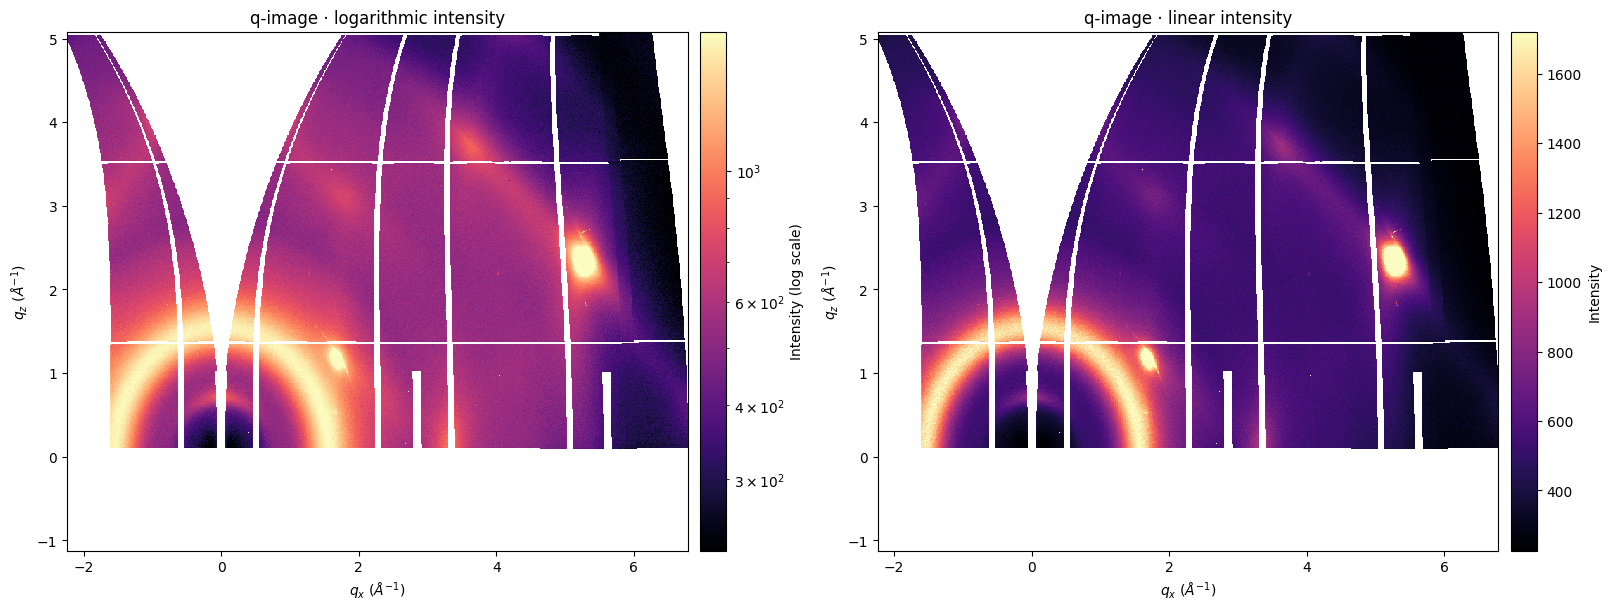

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
plot_qimage(qimage, ax=axes[0], log_intensity=True, aspect='auto',
            max_pixels=MAX_PLOT_PIXELS, title='q-image · logarithmic intensity')
plot_qimage(qimage, ax=axes[1], log_intensity=False, aspect='auto',
            max_pixels=MAX_PLOT_PIXELS, title='q-image · linear intensity')
plt.show()

## 4. Crop the physically interesting q-range

Change these limits to inspect the Yoneda region, beamstop region, or high-q region. The crop is performed in q coordinates, not array indices.

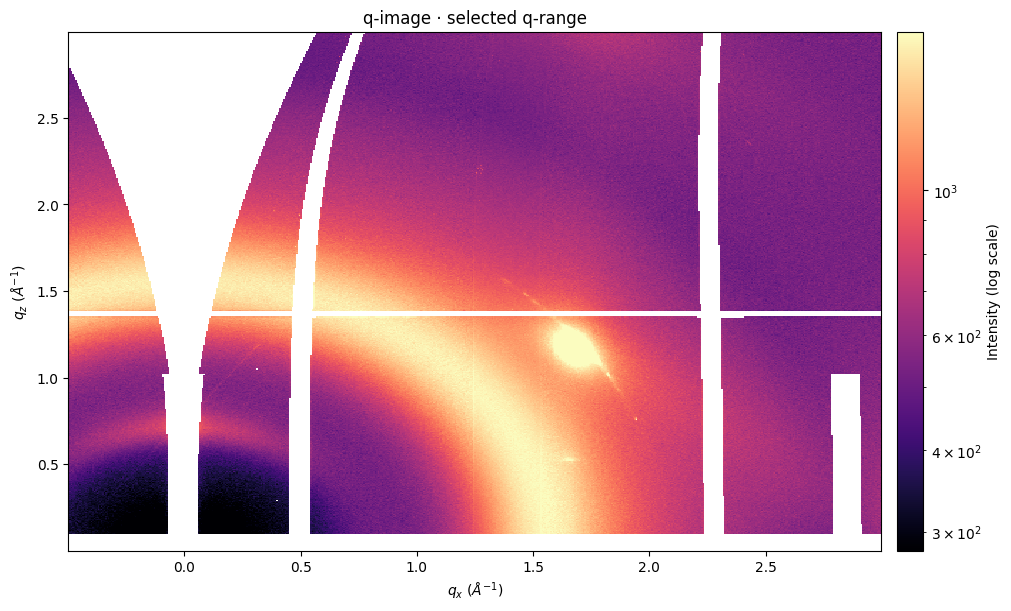

In [5]:
QX_LIMITS = (-0.5, 3.0)
QZ_LIMITS = (0.0, 3.0)
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
plot_qimage(qimage, ax=ax, qxlim=QX_LIMITS, qzlim=QZ_LIMITS,
            log_intensity=True, aspect='auto',
            max_pixels=MAX_PLOT_PIXELS, title='q-image · selected q-range')
plt.show()

## 5. One-dimensional q-image checks

These nearest-row and nearest-column profiles are useful for determining whether the apparent display problem comes from the map itself or only from the GUI color/axis settings.

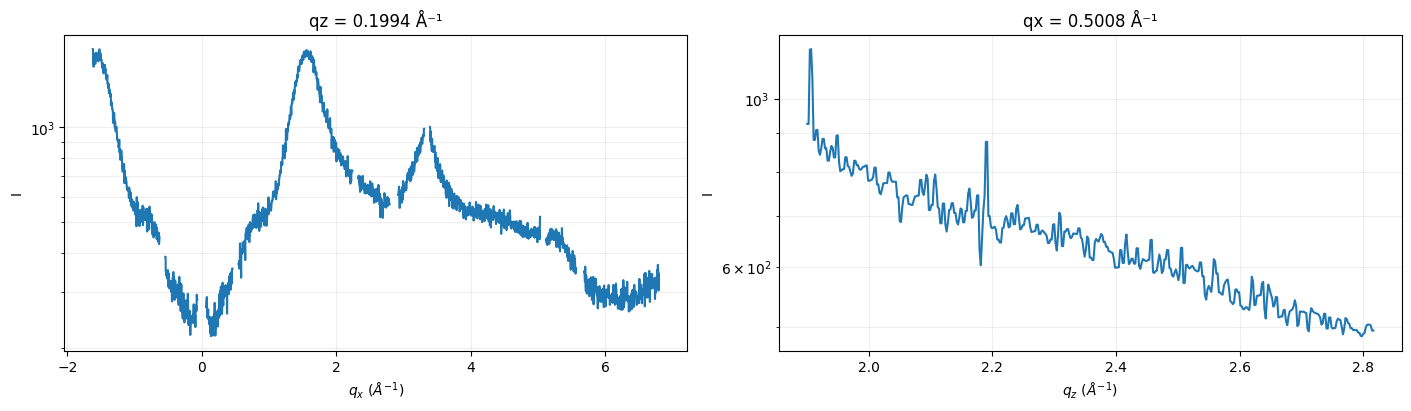

In [6]:
CUT_QZ = 0.20
CUT_QX = 0.50
cuts = qimage_linecuts(qimage, qx=CUT_QX, qz=CUT_QZ)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
axes[0].plot(cuts['qx'], cuts['qx_profile'])
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$q_x$ ($\AA^{-1}$)')
axes[0].set_ylabel('I')
axes[0].set_title(f"qz = {cuts['selected_qz']:.4g} Å⁻¹")
axes[1].plot(cuts['qz'], cuts['qz_profile'])
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$q_z$ ($\AA^{-1}$)')
axes[1].set_ylabel('I')
axes[1].set_title(f"qx = {cuts['selected_qx']:.4g} Å⁻¹")
for ax in axes: ax.grid(True, which='both', alpha=0.2)
plt.show()

## 6. Compare the q-image with q–φ and I(q) for the same frame

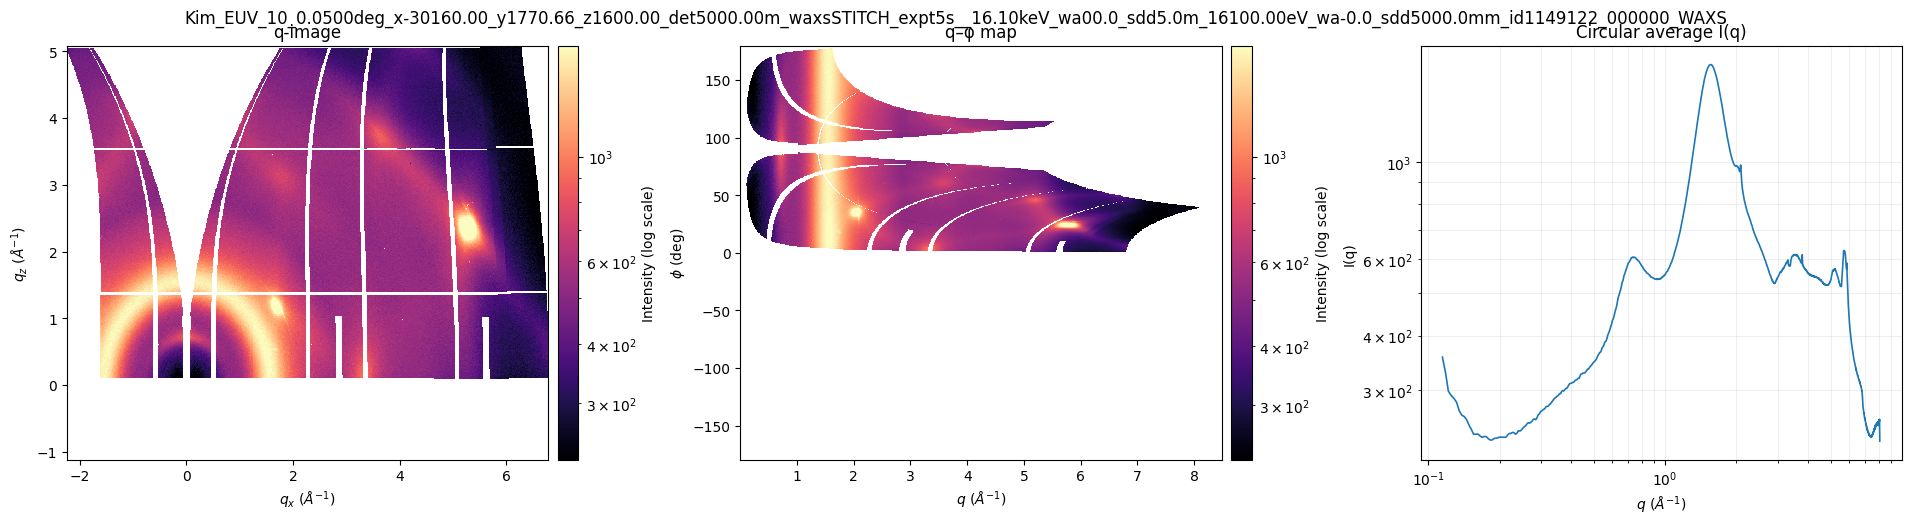

In [7]:
stem = frame_table.iloc[FRAME_INDEX]['stem']
row = frame_table.iloc[FRAME_INDEX]
fig, axes = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)
plot_qimage(qimage, ax=axes[0], log_intensity=True, aspect='auto',
            max_pixels=MAX_PLOT_PIXELS, title='q-image')
if row.get('has_qphi', False):
    qphi = load_qphi(row['qphi'])
    plot_qphi(qphi, ax=axes[1], log_intensity=True, title='q–φ map')
else:
    axes[1].set_title('No q–φ product for this frame')
if row.get('has_cir_avg', False):
    plot_cir_avg(row['cir_avg'], ax=axes[2], title='Circular average I(q)')
else:
    axes[2].set_title('No circular-average product for this frame')
fig.suptitle(stem, y=1.02)
plt.show()